In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score



In [ ]:
def get_regression_metrics(y_predict_test, y_test, y_predict_train, y_train):

    metrics_train = (r2_score(y_train, y_predict_train),
                     median_absolute_error(y_train, y_predict_train),
                     mean_absolute_percentage_error(y_train, y_predict_train) * 100,
                     mean_squared_error(y_train, y_predict_train),
                     root_mean_squared_error(y_train, y_predict_train))
    
    metrics_test = (r2_score(y_test, y_predict_test),
                    median_absolute_error(y_test, y_predict_test),
                    mean_absolute_percentage_error(y_test, y_predict_test) * 100,
                    mean_squared_error(y_test, y_predict_test),
                    root_mean_squared_error(y_test, y_predict_test))
    
    metrics_diff = list(map(lambda x: x[1] - x[0], zip(metrics_train, metrics_test)))
    
    return pd.DataFrame(data=[metrics_train, metrics_test, metrics_diff],
                        columns=['R2', 'MAE', 'MAPE', 'MSE', 'RMSE'],
                        index=['Train set', 'Test set', 'Difference'])

In [ ]:
def get_classifier_metrics(y_predict_test, y_test, y_predict_train, y_train, average='micro'):

    metrics_train = (accuracy_score(y_train, y_predict_train),
                     f1_score(y_train, y_predict_train, average=average),
                     precision_score(y_train, y_predict_train, average=average),
                     recall_score(y_train, y_predict_train, average=average))
    
    metrics_test = (accuracy_score(y_test, y_predict_test),
                    f1_score(y_test, y_predict_test, average=average),
                    precision_score(y_test, y_predict_test, average=average),
                    recall_score(y_test, y_predict_test, average=average))
    
    return pd.DataFrame(data=[metrics_train, metrics_test],
                        columns=['Accuracy', 'F1 Score', 'Precision', 'Recall'],
                        index=['Train set', 'Test set'])

In [ ]:
X_train = pd.read_csv('../data/processed/X_train_eda7.csv')
X_test = pd.read_csv('../data/processed/X_test_eda7.csv')
y_train = pd.read_csv('../data/processed/y_train_eda7.csv')
y_test = pd.read_csv('../data/processed/y_test_eda7.csv')

In [ ]:
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [ ]:
y_pred = tree_clf.predict(X_test)

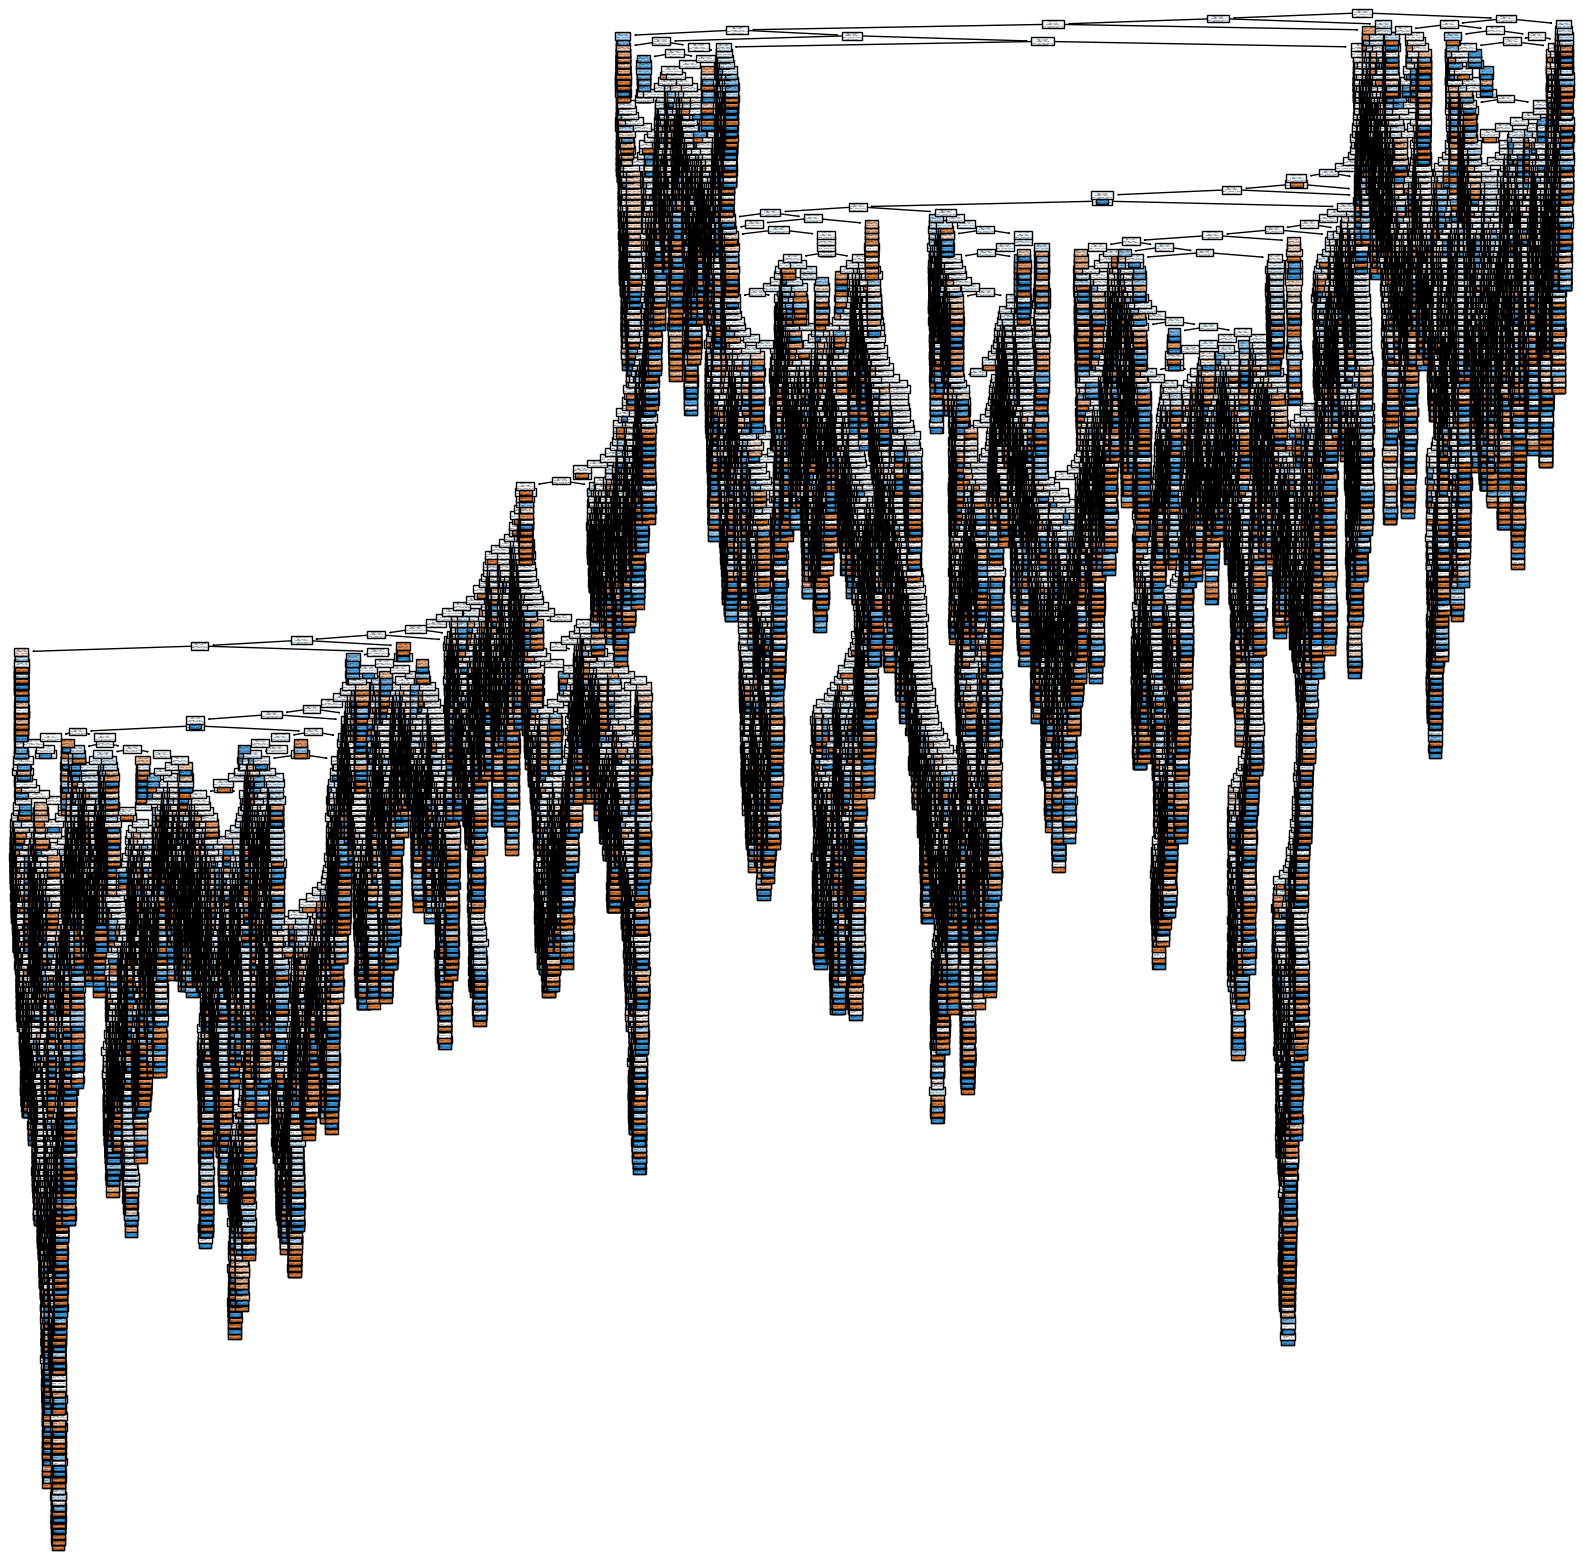

In [8]:
plt.figure(figsize=(20, 20))

tree.plot_tree(tree_clf,
               feature_names=list(X_train.columns),
               class_names=['negativo', 'positivo'],
               filled=True)
plt.show()

In [9]:
y_pred_test = tree_clf.predict(X_test)
y_pred_test

array([1, 0, 1, ..., 0, 0, 0], shape=(124019,))

In [10]:
y_pred_train = tree_clf.predict(X_train)
y_pred_train

array([0, 1, 1, ..., 0, 0, 0], shape=(496076,))

In [11]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train)

,Accuracy,F1 Score,Precision,Recall
Train set,1.00000,1.00000,1.00000,1.00000
Test set,0.49948,0.49948,0.49948,0.49948


In [ ]:
param_grid = {'max_depth': [3, 4, 5, 6, None],
              'min_samples_split': [2, 5, 10, 20],
              'min_samples_leaf': [1, 2, 4, 10],
              'criterion': ['gini', 'entropy']}

grid = GridSearchCV(estimator=tree_clf,
                    param_grid=param_grid,
                    cv=5,               # 5-fold cross validation
                    scoring='accuracy',
                    n_jobs=-1)           # usa todos los núcleos del CPU


In [ ]:
grid.fit(X_train, y_train)

f'mejores hiperparametros {grid.best_params_} Mejor accuracy en CV: {grid.best_score_}'
best_tree = grid.best_estimator_

In [ ]:
y_pred_best = best_tree.predict(X_test)

f'Accuracy:', accuracy_score(y_test, y_pred_best)

Accuracy: 0.523806836049315

Reporte:
               precision    recall  f1-score   support

           0       0.50      0.03      0.05     59054
           1       0.52      0.98      0.68     64965

    accuracy                           0.52    124019
   macro avg       0.51      0.50      0.37    124019
weighted avg       0.51      0.52      0.38    124019



In [ ]:
f'\nReporte:\n', classification_report(y_test, y_pred_best)